# ✈️ Aircraft Digital Twin - Core Flow Demo

Notebook này minh họa luồng hoạt động chính yếu của hệ thống
Bỏ qua các bước thử nghiệm, test model phụ (như Random Forest) và đi thẳng vào **Digital Twin** với **LSTM** và **PPO**.

In [1]:
import os
import sys
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scripts.evaluation.eval_utils import evaluate_lstm_performance
from scripts.evaluation.rl_eval import evaluate_rl_agent

from sklearn.metrics import r2_score

import importlib
import scripts.models.lstm_model
import scripts.evaluation.eval_utils
# Reload các module để cập nhật code mới nhất từ file .py
importlib.reload(scripts.models.lstm_model)
importlib.reload(scripts.evaluation.eval_utils)

# Ensure project root is in path
PROJECT_ROOT = os.getcwd()
sys.path.insert(0, PROJECT_ROOT)

from scripts.data.data_processor import prepare_data, FEATURES, KEY_SENSORS
from scripts.models.lstm_model import create_sequences, train_model
from scripts.core.aircraft_env import AircraftEnv

I0000 00:00:1778310704.433446    7453 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778310704.434038    7453 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778310704.480586    7453 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778310705.884134    7453 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

## 1. Load Dữ Liệu

In [2]:
data_dir = os.path.join(PROJECT_ROOT, 'CMAPSSData') 
train_rolling, test_rolling, true_rul, scaler = prepare_data(data_dir)
print("Dữ liệu đã được nạp thành công!")

Loaded CMAPSS data: 20631 train rows, 13096 test rows, 100 engines
Scaler fitted on 16 features
Dữ liệu đã được nạp thành công!


## 2. Huấn Luyện hoặc Load LSTM Model

In [3]:
# Định nghĩa đường dẫn lưu model
model_path = os.path.join(PROJECT_ROOT, 'models', 'lstm_rul_model.keras')

if os.path.exists(model_path):
    lstm_model = tf.keras.models.load_model(model_path)
    print(f"📦 Đã load LSTM model thành công từ: {model_path}")
else:
    print("🧠 Không tìm thấy model có sẵn. Bắt đầu huấn luyện LSTM mới...")
    # Chuẩn bị sequence cho training
    X_train, y_train = create_sequences(train_rolling, scaler)
    # Train model (epochs thấp để demo chạy nhanh)
    lstm_model, history = train_model(X_train, y_train, epochs=54)
    
    # Lưu model
    os.makedirs(os.path.dirname(model_path), exist_ok=True)
    lstm_model.save(model_path)
    print(f"💾 Đã huấn luyện và lưu LSTM model tại: {model_path}")

📦 Đã load LSTM model thành công từ: /home/tung/NT549-Project/models/lstm_rul_model.keras


E0000 00:00:1778310718.812085    7453 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 2.1 Đánh Giá Model LSTM

Chúng ta sẽ đánh giá model trên tập test bằng chỉ số **R2 Score** và vẽ biểu đồ **Loss** trong quá trình huấn luyện.

📊 Calculating metrics on the test set...
✅ R2 Score:  0.8604
✅ RMSE:      15.53 cycles
✅ MAE:       11.28 cycles


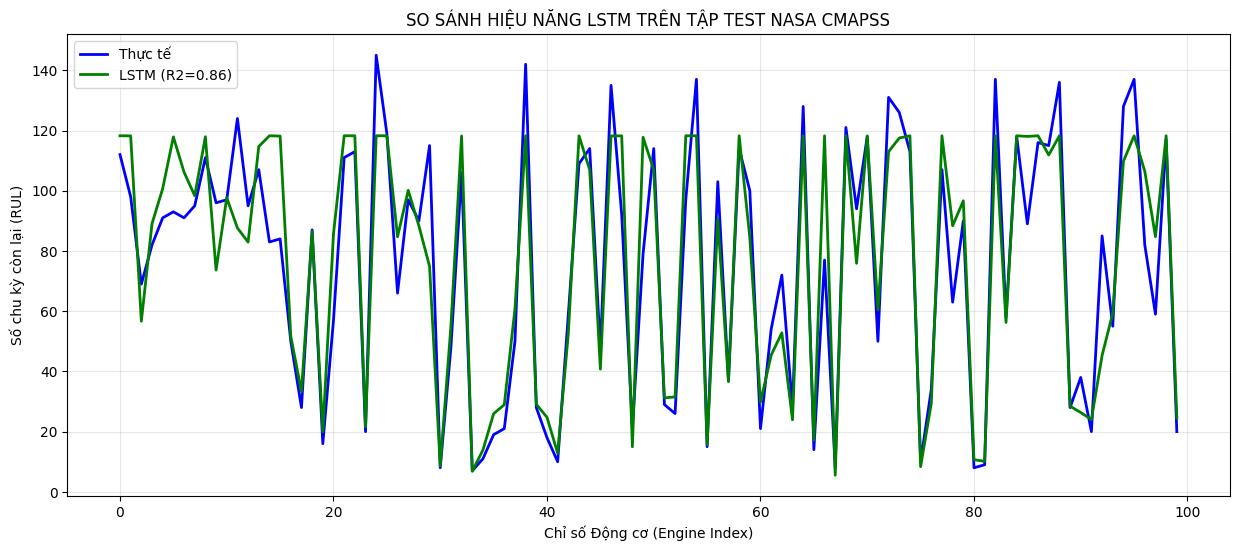

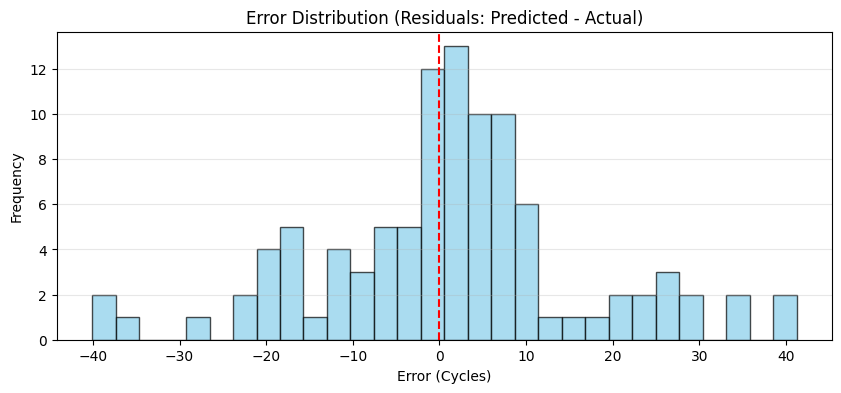

In [5]:
# Tính RMSE, MAE và vẽ biểu đồ phân phối lỗi
y_true, y_pred = evaluate_lstm_performance(lstm_model, test_rolling, true_rul, scaler)

## 3. Khởi Tạo Môi Trường Mô Phỏng (RL Environment)

In [6]:
env = AircraftEnv(
    fleet_data=train_rolling,
    model_path=model_path,
    scaler=scaler,
    sensor_list=KEY_SENSORS,
    features_list=FEATURES
)

print("✈️ Khởi tạo môi trường Digital Twin hoàn tất.")

✈️ Khởi tạo môi trường Digital Twin hoàn tất.


## 4. Huấn luyện Agent (PPO - Reinforcement Learning)

In [7]:
import os
import mlflow
import importlib
from datetime import datetime
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import SubprocVecEnv, VecNormalize
from stable_baselines3.common.env_util import make_vec_env  
from stable_baselines3.common.callbacks import EvalCallback, CallbackList
from typing import Callable
from stable_baselines3.common.utils import get_linear_fn

# Use fixed LR for this shaped-reward environment; a decayed LR often freezes a weak deterministic policy.
learning_rate = 3e-4

# Reload custom scripts to pick up changes
import scripts.training.rl_callbacks
importlib.reload(scripts.training.rl_callbacks)
from scripts.training.rl_callbacks import (
    SaveVecNormalizeCallback, 
    MLflowLoggingCallback, 
    SyncVecNormalizeCallback,
    EvalDiagnosticsCallback
)

# --- Configuration ---
# 👉 Change this name for each training run to keep them organized!
RUN_NAME = None  # Example: "experiment_v1"

# --- MLFlow Configuration ---
mlflow.set_tracking_uri("http://localhost:5000") 
mlflow.set_experiment("Aircraft_Predictive_Maintenance_v2")

# Auto-generate run name if not provided
if RUN_NAME is None:
    RUN_NAME = f"PPO_Run_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
print(f"🏷️ Training run name: {RUN_NAME}")

# Paths for model and normalization stats
repo_ppo_path = os.path.join(PROJECT_ROOT, 'models', f'ppo_aircraft_{RUN_NAME}')
stats_path = os.path.join(PROJECT_ROOT, 'models', f'ppo_aircraft_{RUN_NAME}_vec_normalize.pkl')
best_model_dir = os.path.join(PROJECT_ROOT, 'models', f'best_ppo_{RUN_NAME}')

os.makedirs(best_model_dir, exist_ok=True)

def make_env():
    # SubprocVecEnv uses forkserver/spawn and must pickle this factory.
    # Do NOT capture train_rolling/scaler DataFrame objects from the notebook;
    # load them inside each worker to keep the factory pickle-safe.
    from scripts.data.data_processor import prepare_data, FEATURES, KEY_SENSORS
    from scripts.core.aircraft_env import AircraftEnv

    worker_data_dir = os.path.join(PROJECT_ROOT, 'CMAPSSData')
    worker_train_rolling, _, _, worker_scaler = prepare_data(worker_data_dir)

    return AircraftEnv(
        fleet_data=worker_train_rolling,
        model_path=model_path,
        scaler=worker_scaler,
        sensor_list=KEY_SENSORS,
        features_list=FEATURES
    )

# --- Check for existing model ---
if os.path.exists(repo_ppo_path + ".zip") and os.path.exists(stats_path):
    print(f"📦 Loading PPO agent and normalization stats from: {repo_ppo_path}")
    train_env = make_vec_env(make_env, n_envs=1)
    train_env = VecNormalize.load(stats_path, train_env)
    train_env.training = False
    train_env.norm_reward = False
    ppo_model = PPO.load(repo_ppo_path, env=train_env)
else:
    print(f"🚀 Training PPO Agent (1000k steps) with EvalCallback and MLflow...")
    
    with mlflow.start_run(run_name=RUN_NAME):
        # 1. Setup Training Env
        n_envs = 4
        train_env = make_vec_env(make_env, n_envs=n_envs, vec_env_cls=SubprocVecEnv)
        train_env = VecNormalize(train_env, norm_obs=True, norm_reward=True, clip_obs=10.)
        
        # 2. Setup Eval Env (Stats will be synced from train_env)
        eval_env = make_vec_env(make_env, n_envs=1)
        eval_env = VecNormalize(eval_env, norm_obs=True, norm_reward=False, clip_obs=10., training=False)
        
        # 3. Initialize PPO
        ppo_model = PPO(
            "MlpPolicy", 
            train_env, 
            verbose=1,
            learning_rate=learning_rate,
            ent_coef=0.05,
            tensorboard_log=os.path.join(PROJECT_ROOT, 'logs', 'ppo_demo')
        )
        
        # 4. Log Hyperparameters to MLflow
        params = {
            "total_timesteps": 1000000,
            "learning_rate": 3e-4,
            "n_envs": n_envs,
            "run_name": RUN_NAME,
            "gamma": 0.99
        }
        mlflow.log_params(params)
        
        # 5. Set up Callback Chain
        # IMPORTANT: Sync stats TO eval_env before every evaluation
        sync_cb = SyncVecNormalizeCallback(eval_env=eval_env, verbose=1)
        save_vec_stats_cb = SaveVecNormalizeCallback(save_path=best_model_dir, verbose=1)
        eval_diag_det_cb = EvalDiagnosticsCallback(
            eval_env=eval_env,
            eval_freq=10000,
            n_eval_episodes=10,
            deterministic=True,
            log_prefix="eval_diag_det",
            verbose=1
        )
        eval_diag_stoch_cb = EvalDiagnosticsCallback(
            eval_env=eval_env,
            eval_freq=20000,
            n_eval_episodes=10,
            deterministic=False,
            log_prefix="eval_diag_stoch",
            verbose=1
        )
        
        eval_callback = EvalCallback(
            eval_env, 
            best_model_save_path=best_model_dir,
            log_path=os.path.join(PROJECT_ROOT, 'logs', 'eval_results'), 
            eval_freq=5000, 
            deterministic=True, 
            callback_on_new_best=save_vec_stats_cb,
            callback_after_eval=None # Custom logic could go here
        )
        
        mlflow_cb = MLflowLoggingCallback(verbose=1)
        
        # Combine everything: Sync -> Eval (which triggers Save) -> diagnostics -> MLflow
        callback_list = CallbackList([sync_cb, eval_callback, eval_diag_det_cb, eval_diag_stoch_cb, mlflow_cb])
        
        # 6. Start Training
        ppo_model.learn(total_timesteps=params["total_timesteps"], callback=callback_list)
        
        # 7. Final Saving & Artifact Logging
        ppo_model.save(repo_ppo_path)
        train_env.save(stats_path)
        
            
        print(f"💾 Done! Model and stats uploaded to MLflow.")

print("✅ PPO System Ready!")


🏷️ Training run name: PPO_Run_20260509_071654
🚀 Training PPO Agent (1000k steps) with EvalCallback and MLflow...


I0000 00:00:1778311016.420103    7924 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778311016.482231    7924 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778311017.888934    7924 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778311017.889465    7924 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.

🏃 View run PPO_Run_20260509_071654 at: http://localhost:5000/#/experiments/1/runs/9c65a79fcb0e473ea37cd28407b72146
🧪 View experiment at: http://localhost:5000/#/experiments/1


KeyboardInterrupt: 

## 5. Chạy Một Chuyến Bay (Demo Episode)

In [12]:
# Chạy thử 20 episodes trên tập Test để xem tỷ lệ thành công
eval_results = evaluate_rl_agent(ppo_model, test_rolling, lstm_model, scaler, num_episodes=20)

TypeError: AircraftEnv.__init__() got an unexpected keyword argument 'model'